INFO     | ======================================================================
INFO     | Starting analysis: figure_01
INFO     | Log file: outputs/logs/figure_01_20260623_122952.log
INFO     | Timestamp: 2026-06-23 12:29:52
INFO     | ======================================================================
INFO     | Loading configuration...
INFO     | Periods: (1979, 2015) and (2015, 2026)
INFO     | Breakpoint year: 2015
INFO     | Functions defined
INFO     | Processing: PART 1: Loading cached spatial trends (REPROCESS=False)
INFO     | Loaded: spatial_trends_period1.nc, spatial_trends_period2.nc, era5_ice_edge_months.nc
INFO     | Processing: PART 2: Loading cached OSISAF annual maxima (REPROCESS=False)
INFO     | Loaded: annual_max_sie_dates.csv (48 years)
INFO     | NH annual max range: 14.420 – 16.562 ×10⁶ km²
INFO     | GS annual max range: 0.4325 – 0.8750 ×10⁶ km²
INFO     | Loading ETOPO1 data from: rockhound.fetch_etopo1
INFO     | Panel (c) ice edge: month forced to March

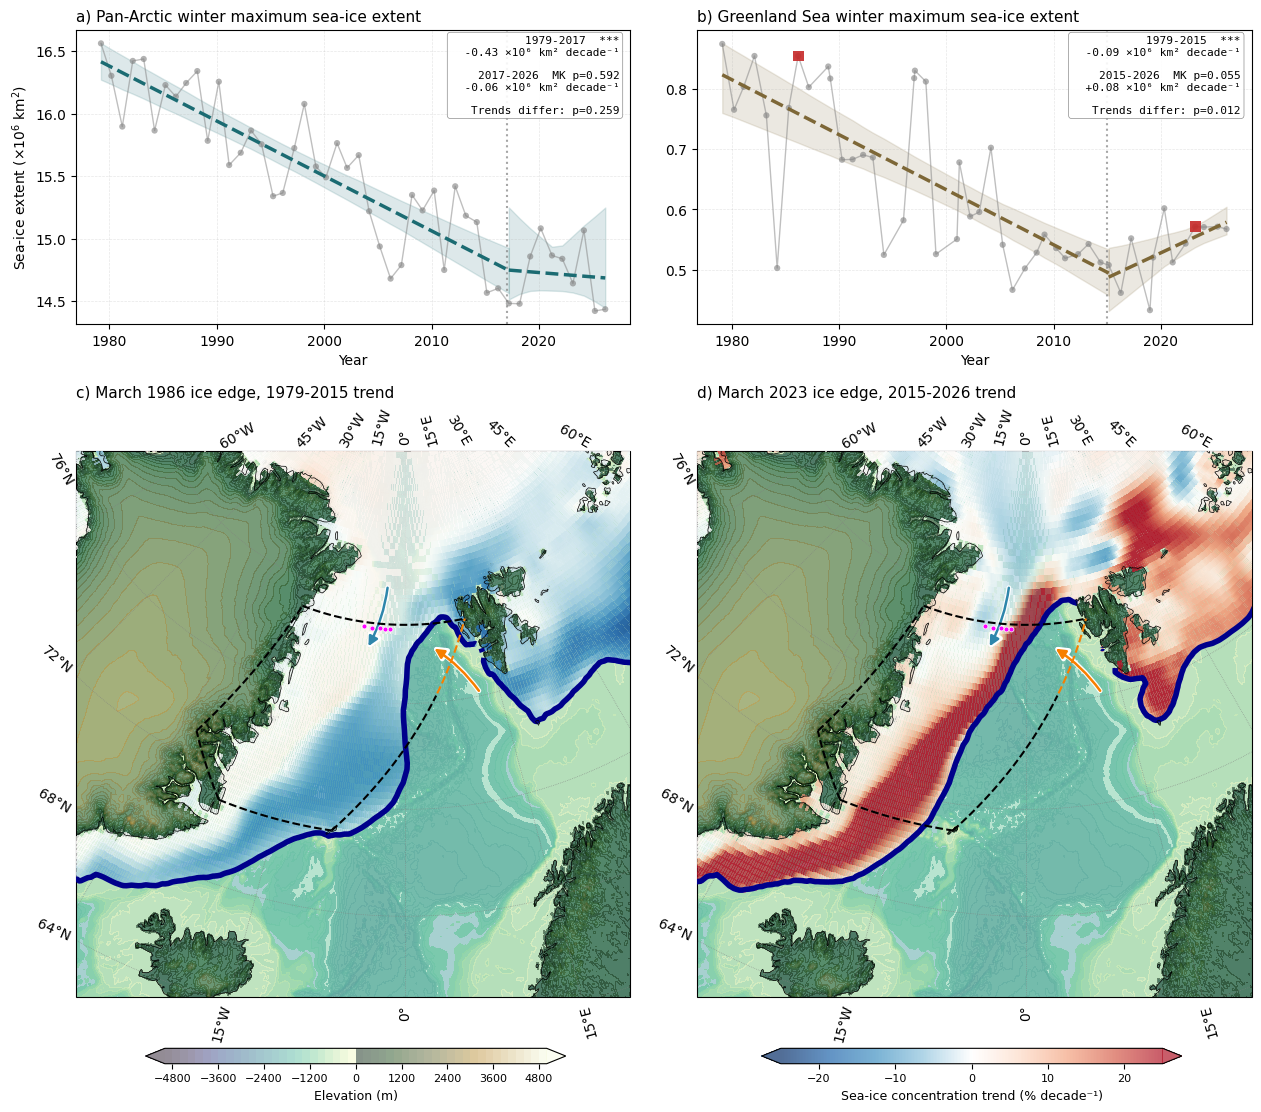

INFO     | Methods documentation saved: outputs/methods/figure_01_methods.md
INFO     | Created methods: figure_01_methods.md
INFO     | ======================================================================
INFO     | Analysis completed successfully
INFO     | Total elapsed time: 0:01:46
INFO     | ======================================================================
INFO     | ======================================================================
INFO     | FIGURE 1 COMPLETE
INFO     | ======================================================================


In [2]:
"""
Figure 1: Spatial SIC Trends and Annual Maximum Sea Ice Extent Timeseries
===========================================================================

Four-panel figure:
- Panel (a): Pan-Arctic annual maximum SIE timeseries with split linear trends
- Panel (b): Greenland Sea annual maximum SIE timeseries with split linear trends
- Panel (c): Ice edge for max March year in P1 with 1979-2015 spatial trends
- Panel (d): Ice edge for max March year in P2 with 2015-2025 spatial trends

Version: 1.1.0
Last Modified: 22-06-2026
Author: Chris Barrell
"""

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as dates
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker
import cmocean
import rockhound as rh
import pwlf
from scipy import stats
import os
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setup logging
import sys
sys.path.append('..')
from utils.logger import (setup_logger, log_data_loading, log_processing_step,
                          log_output_file, log_completion, log_error)

# ============================================================================
# REPROCESS FLAG
# Set to True to recompute all processed data from raw source files.
# Set to False (default) to load cached files from outputs/processed_data/
# and skip PWLR/date-of-maximum diagnostics (which require raw daily data).
# ============================================================================
REPROCESS = False

logger = setup_logger('figure_01', config_path='../config.yaml')
start_time = datetime.now()

try:
    # ========================================================================
    # CONFIGURATION
    # ========================================================================

    logger.info("Loading configuration...")

    # File paths
    ERA5_PATH = '../../era5/era5_*_Arctic.nc'
    OSISAF_PATH = '../../osi-sea_ice_index/'

    # Create output directories
    OUTPUT_DIR = Path('./outputs/figures')
    PROCESSED_DIR = Path('./outputs/processed_data/figure_01')
    METHODS_DIR = Path('./outputs/methods')

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    METHODS_DIR.mkdir(parents=True, exist_ok=True)

    # Start year for timeseries analysis — filters out incomplete earlier years
    START_YEAR = 1979

    # Representative years for spatial panels — the month of the Greenland Sea
    # annual maximum for these years is looked up dynamically from the date table.
    MAX_YEAR_P1 = 1986
    MAX_YEAR_P2 = 2023

    # Optional: force the month used for the panel (d) ice edge contour.
    # Set to an integer (1-12) to override the dynamic GS annual max month,
    # or None to use the month of the GS annual maximum for MAX_YEAR_P2.
    FORCE_P1_MONTH = 3  # set to None to use dynamic GS annual max month
    FORCE_P2_MONTH = 3  # e.g. 3 = March; set to None to use dynamic month

    # Analysis periods
    PERIOD_1 = (1979, 2015)
    PERIOD_2 = (2015, 2026)
    BREAKPOINT_YEAR = 2015

    # Spatial extents
    TREND_EXTENT = {'lon_min': -90, 'lon_max': 90, 'lat_min': 60, 'lat_max': 90}
    MAP_EXTENT = [-30, 20, 65, 85]

    # Region definitions
    GREENLAND_SEA_COORDS = [(-22, 71), (-8.5, 71), (12, 79), (-21, 79), (-28, 73), (-22, 71)]
    VERTICES = {'NW': (-21, 79), 'NE': (12, 79), 'SE': (-8.5, 71),
                'SW': (-22, 71), 'W_Mid': (-28, 73)}

    # Plotting parameters
    SIC_THRESHOLD = 0.15
    RELIEF_ALPHA = 0.5
    TREND_ALPHA = 0.7
    DPI = 600

    # Colors
    COLOR_BOUNDARY = 'black'
    COLOR_ICE_EDGE = 'darkblue'
    COLOR_ARCTIC = '#1B6B72'      # dark teal
    COLOR_GS = '#7D6737'          # bronze
    COLOR_DATA = '#808080'        # Gray for data points
    COLOR_BREAKPOINT = '#808080'  # Gray for breakpoint line
    CI_ALPHA = 0.15

    # Colormap for trends
    colors_trend = ['#08306b', '#2166ac', '#4393c3', '#92c5de', 'white',
                    '#fddbc7', '#f4a582', '#d6604d', '#b2182b']
    cmap_trend = LinearSegmentedColormap.from_list('red_white_blue', colors_trend, N=256)

    # Configuration for timeseries
    CONFIG = {
        'show_uncertainty_bands': True,
        'show_rate_annotations': False,
        'uncertainty_method': 'bootstrap',
        'confidence_level': 0.95,
        'n_bootstrap': 1000,
    }

    logger.info(f"Periods: {PERIOD_1} and {PERIOD_2}")
    logger.info(f"Breakpoint year: {BREAKPOINT_YEAR}")

    # ========================================================================
    # FUNCTIONS
    # ========================================================================

    def calculate_spatial_trends_vectorized(data_array, time_dim='time'):
        """Calculate linear trends for each grid cell."""
        logger.debug("Calculating spatial trends (vectorized)...")

        time_values = data_array[time_dim].values
        years = pd.to_datetime(time_values).year.values
        time_numeric = years - years[0]
        n_times = len(time_numeric)

        data = data_array.values
        n_lat, n_lon = data.shape[1], data.shape[2]
        data_reshaped = data.reshape(n_times, -1)

        slope = np.full(n_lat * n_lon, np.nan)
        pvalue = np.full(n_lat * n_lon, np.nan)
        rsquared = np.full(n_lat * n_lon, np.nan)

        n_valid = np.sum(~np.isnan(data_reshaped), axis=0)
        valid_cells = n_valid >= 5

        logger.debug(f"Valid cells: {valid_cells.sum()} / {len(valid_cells)}")

        if valid_cells.sum() > 0:
            for i in np.where(valid_cells)[0]:
                series = data_reshaped[:, i]
                valid_mask = ~np.isnan(series)

                if valid_mask.sum() >= 5:
                    result = stats.linregress(time_numeric[valid_mask], series[valid_mask])
                    slope[i] = result.slope
                    pvalue[i] = result.pvalue
                    rsquared[i] = result.rvalue ** 2

        slope = slope.reshape(n_lat, n_lon)
        pvalue = pvalue.reshape(n_lat, n_lon)
        rsquared = rsquared.reshape(n_lat, n_lon)

        spatial_dims = [d for d in data_array.dims if d != time_dim]
        spatial_coords = {dim: data_array[dim] for dim in spatial_dims}

        slope_da = xr.DataArray(slope, coords=spatial_coords, dims=spatial_dims)
        pvalue_da = xr.DataArray(pvalue, coords=spatial_coords, dims=spatial_dims)
        rsquared_da = xr.DataArray(rsquared, coords=spatial_coords, dims=spatial_dims)

        logger.debug(f"Slope range: {np.nanmin(slope):.6f} to {np.nanmax(slope):.6f} yr⁻¹")

        return slope_da, pvalue_da, rsquared_da


    def bootstrap_trend_ci(x, y, n_bootstrap=1000, confidence=0.95):
        """Bootstrap confidence intervals for linear trend."""
        x = np.asarray(x)
        y = np.asarray(y)

        n = len(y)
        trends = []
        predictions = np.zeros((n_bootstrap, n))

        for i in range(n_bootstrap):
            indices = np.random.choice(n, size=n, replace=True)
            x_boot = x[indices]
            y_boot = y[indices]

            z = np.polyfit(x_boot, y_boot, 1)
            p = np.poly1d(z)

            trend = (p(x[-1]) - p(x[0])) / len(x)
            trends.append(trend)
            predictions[i, :] = p(x)

        alpha = 1 - confidence
        lower_percentile = (alpha / 2) * 100
        upper_percentile = (1 - alpha / 2) * 100

        lower_bound = np.percentile(predictions, lower_percentile, axis=0)
        upper_bound = np.percentile(predictions, upper_percentile, axis=0)
        trend_ci = (np.percentile(trends, lower_percentile),
                    np.percentile(trends, upper_percentile))

        return {'lower_bound': lower_bound, 'upper_bound': upper_bound, 'trend_ci': trend_ci}


    def mann_kendall_test(x, y):
        """Mann-Kendall trend test for monotonic trends."""
        y = np.asarray(y)
        n = len(y)
        s = 0

        for i in range(n-1):
            for j in range(i+1, n):
                s += np.sign(y[j] - y[i])

        var_s = n * (n - 1) * (2 * n + 5) / 18

        if s > 0:
            z = (s - 1) / np.sqrt(var_s)
        elif s < 0:
            z = (s + 1) / np.sqrt(var_s)
        else:
            z = 0

        p_value = 2 * (1 - stats.norm.cdf(abs(z)))
        tau = s / (0.5 * n * (n - 1))

        if p_value < 0.05:
            trend = 'increasing' if tau > 0 else 'decreasing'
        else:
            trend = 'no trend'

        if p_value < 0.001:
            significance = '***'
        elif p_value < 0.01:
            significance = '**'
        elif p_value < 0.05:
            significance = '*'
        else:
            significance = 'n.s.'

        return {'tau': tau, 'p_value': p_value, 'trend': trend, 'significance': significance}


    def compare_trends(x1, y1, x2, y2):
        """Test if two trends are significantly different (Chow test)."""
        x1, y1 = np.asarray(x1), np.asarray(y1)
        x2, y2 = np.asarray(x2), np.asarray(y2)

        slope1, intercept1, _, _, _ = stats.linregress(x1, y1)
        slope2, intercept2, _, _, _ = stats.linregress(x2, y2)

        y1_fit = slope1 * x1 + intercept1
        y2_fit = slope2 * x2 + intercept2
        rss1 = np.sum((y1 - y1_fit)**2)
        rss2 = np.sum((y2 - y2_fit)**2)
        rss_separate = rss1 + rss2

        x_pooled = np.concatenate([x1, x2])
        y_pooled = np.concatenate([y1, y2])
        slope_pooled, intercept_pooled, _, _, _ = stats.linregress(x_pooled, y_pooled)
        y_pooled_fit = slope_pooled * x_pooled + intercept_pooled
        rss_pooled = np.sum((y_pooled - y_pooled_fit)**2)

        n1, n2 = len(y1), len(y2)
        k = 2
        f_statistic = ((rss_pooled - rss_separate) / k) / (rss_separate / (n1 + n2 - 2*k))
        p_value = 1 - stats.f.cdf(f_statistic, k, n1 + n2 - 2*k)

        return {'f_statistic': f_statistic, 'p_value': p_value,
                'significant': p_value < 0.05, 'slope_diff': slope2 - slope1}


    def get_trend(x, y):
        """Calculate linear trend with statistics."""
        x, y = np.asarray(x), np.asarray(y)
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        trend = (p(x[-1]) - p(x[0])) / len(x)
        result = stats.linregress(x, y)
        return p, trend, {'r_squared': result.rvalue**2, 'p_value': result.pvalue}


    def fetch_sie(region, sie_list):
        """Fetch sea ice extent data for specified region."""
        for sie in sie_list:
            if sie.name == region:
                return sie
        raise ValueError(f"Region '{region}' not found in sie_list")


    def extract_annual_max(ds_daily):
        """
        Extract annual maximum SIE from daily data.

        Returns
        -------
        ann_max : pd.Series
            Annual maximum SIE indexed by year (float).
        ann_max_dates : pd.Series
            Date of the annual maximum indexed by year.
        ann_max_timestamps : list of pd.Timestamp
            Timestamps of the annual maximum, one per year, for use as
            matplotlib x-axis values (plotted at mid-year for clarity).
        """
        df = ds_daily.to_dataframe(name='sie').reset_index()
        df = df.rename(columns={df.columns[0]: 'time'})
        df['time'] = pd.to_datetime(df['time'])
        df['year'] = df['time'].dt.year

        records = []
        for year, grp in df.groupby('year'):
            idx = grp['sie'].idxmax()
            records.append({
                'year': year,
                'sie': grp.loc[idx, 'sie'],
                'date': grp.loc[idx, 'time'],
            })

        result = pd.DataFrame(records).set_index('year')
        ann_max = result['sie']
        ann_max_dates = result['date']

        # Use actual date of maximum as the x coordinate
        ann_max_timestamps = [pd.Timestamp(d) for d in ann_max_dates]

        return ann_max, ann_max_dates, ann_max_timestamps



    def seasonal_extreme(da, mode='max'):
        """
        Extract winter maximum (or summer minimum) SIE per season year
        from daily data.

        Winter window: Oct-Apr, labelled by the year in which April falls
        (end-year convention, consistent with project winter labelling).
        Summer window: Jun-Sep, labelled by that calendar year.

        Seasons with fewer than 30 daily observations are excluded as
        incomplete. Used here to replicate the S1 PWLR methodology exactly.
        """
        times = pd.DatetimeIndex(da.time.values)
        values = da.values

        if mode == 'max':
            winter_years = np.where(times.month >= 10, times.year + 1, times.year)
            in_window = np.isin(times.month, [10, 11, 12, 1, 2, 3, 4])
            winter_years = winter_years[in_window]
            values_win = values[in_window]
            times_win = times[in_window]

            years_out, extremes, extreme_dates = [], [], []
            for yr in np.unique(winter_years):
                mask = winter_years == yr
                if mask.sum() < 30:
                    continue
                if np.all(np.isnan(values_win[mask])):
                    continue
                idx = np.nanargmax(values_win[mask])
                years_out.append(yr)
                extremes.append(values_win[mask][idx])
                extreme_dates.append(times_win[mask][idx])
        else:
            in_window = np.isin(times.month, [6, 7, 8, 9])
            yr_arr = times.year[in_window]
            values_win = values[in_window]
            times_win = times[in_window]

            years_out, extremes, extreme_dates = [], [], []
            for yr in np.unique(yr_arr):
                mask = yr_arr == yr
                if mask.sum() < 30:
                    continue
                if np.all(np.isnan(values_win[mask])):
                    continue
                idx = np.nanargmin(values_win[mask])
                years_out.append(yr)
                extremes.append(values_win[mask][idx])
                extreme_dates.append(times_win[mask][idx])

        return np.array(years_out), np.array(extremes), extreme_dates

    logger.info("Functions defined")

    # ========================================================================
    # PART 1: CALCULATE SPATIAL TRENDS
    # ========================================================================

    slope_p1_file = PROCESSED_DIR / 'spatial_trends_period1.nc'
    slope_p2_file = PROCESSED_DIR / 'spatial_trends_period2.nc'
    era5_ice_edge_file = PROCESSED_DIR / 'era5_ice_edge_months.nc'

    if REPROCESS:
        log_processing_step(logger, "PART 1: Calculating Spatial Trends (REPROCESS=True)")

        log_data_loading(logger, 'ERA5', ERA5_PATH)
        ds_era5 = xr.open_mfdataset(ERA5_PATH, combine='by_coords')
        if 'valid_time' in ds_era5:
            ds_era5 = ds_era5.rename({'valid_time': 'time'})

        logger.info(f"Time range: {ds_era5.time.min().dt.year.item()} to "
                    f"{ds_era5.time.max().dt.year.item()}")
        logger.info(f"Grid: {len(ds_era5.latitude)} x {len(ds_era5.longitude)}")

        log_processing_step(logger, "Subsetting to trend calculation extent")
        ds_subset = ds_era5.sel(
            longitude=slice(TREND_EXTENT['lon_min'], TREND_EXTENT['lon_max']),
            latitude=slice(TREND_EXTENT['lat_max'], TREND_EXTENT['lat_min'])
        )
        logger.info(f"Subset grid: {len(ds_subset.latitude)} x {len(ds_subset.longitude)}")

        log_processing_step(logger, "Extracting March sea ice concentration")
        sic_march = ds_subset['siconc'].where(ds_subset.time.dt.month == 3).dropna(dim='time', how='all')
        logger.info(f"March timesteps: {len(sic_march.time)}")

        log_processing_step(logger, f"Period 1 ({PERIOD_1[0]}-{PERIOD_1[1]}) spatial trends")
        sic_p1 = sic_march.sel(time=slice(f'{PERIOD_1[0]}-01-01', f'{PERIOD_1[1]}-12-31'))
        logger.info(f"Timesteps: {len(sic_p1.time)}")
        slope_p1, pval_p1, r2_p1 = calculate_spatial_trends_vectorized(sic_p1)
        slope_p1.to_netcdf(slope_p1_file)
        log_output_file(logger, 'processed_data', slope_p1_file)

        log_processing_step(logger, f"Period 2 ({PERIOD_2[0]}-{PERIOD_2[1]}) spatial trends")
        sic_p2 = sic_march.sel(time=slice(f'{PERIOD_2[0]}-01-01', f'{PERIOD_2[1]}-12-31'))
        logger.info(f"Timesteps: {len(sic_p2.time)}")
        slope_p2, pval_p2, r2_p2 = calculate_spatial_trends_vectorized(sic_p2)
        slope_p2.to_netcdf(slope_p2_file)
        log_output_file(logger, 'processed_data', slope_p2_file)

        # ---- Save ERA5 ice edge months for replotting without full ERA5 ----
        # Extract only the two representative months needed for the ice edge
        # contours in panels (c) and (d). Stored as a small 2-timestep file
        # so REPROCESS=False runs do not need access to the full ERA5 dataset.
        log_processing_step(logger, "Saving ERA5 ice edge months")
        p1_month_str = f'{MAX_YEAR_P1}-{FORCE_P1_MONTH:02d}' if FORCE_P1_MONTH else f'{MAX_YEAR_P1}-03'
        p2_month_str = f'{MAX_YEAR_P2}-{FORCE_P2_MONTH:02d}' if FORCE_P2_MONTH else f'{MAX_YEAR_P2}-03'
        era5_edge = ds_era5['siconc'].sel(
            time=[p1_month_str, p2_month_str], method='nearest'
        )
        # Subset to the trend calculation extent (same as spatial trend panels)
        era5_edge = era5_edge.sel(
            longitude=slice(TREND_EXTENT['lon_min'], TREND_EXTENT['lon_max']),
            latitude=slice(TREND_EXTENT['lat_max'], TREND_EXTENT['lat_min'])
        )
        era5_edge.to_netcdf(era5_ice_edge_file)
        log_output_file(logger, 'processed_data', era5_ice_edge_file)

    else:
        log_processing_step(logger, "PART 1: Loading cached spatial trends (REPROCESS=False)")
        slope_p1 = xr.open_dataset(slope_p1_file)['__xarray_dataarray_variable__']
        slope_p2 = xr.open_dataset(slope_p2_file)['__xarray_dataarray_variable__']
        ds_era5 = xr.open_dataset(era5_ice_edge_file)
        logger.info(f"Loaded: {slope_p1_file.name}, {slope_p2_file.name}, "
                    f"{era5_ice_edge_file.name}")

    # ========================================================================
    # PART 2: LOAD OSISAF DAILY DATA AND EXTRACT ANNUAL MAXIMA
    # ========================================================================

    csv_file = PROCESSED_DIR / 'annual_max_sie_dates.csv'

    if REPROCESS:
        log_processing_step(logger, "PART 2: Loading OSISAF daily data and extracting annual maxima (REPROCESS=True)")

        f_list = os.listdir(OSISAF_PATH)

        # ---- Load daily data (no monthly resampling) -----------------------
        sie_list = []
        for f in f_list:
            ds = xr.open_dataset(OSISAF_PATH + f)
            # Keep daily resolution — do NOT resample to monthly
            sie = ds.sie
            f_info = f.split('_')
            region = f_info[1]
            sie = sie.rename(region)
            sie.attrs['title'] = ds.title
            sie_list.append(sie)

        ds_nh_daily = fetch_sie('nh', sie_list)
        ds_gs_daily = fetch_sie('fram', sie_list)

        # ---- Filter to START_YEAR to exclude incomplete earlier years ------
        log_processing_step(logger, f"Filtering daily data to >= {START_YEAR}")
        ds_nh_daily = ds_nh_daily.sel(time=ds_nh_daily.time.dt.year >= START_YEAR)
        ds_gs_daily = ds_gs_daily.sel(time=ds_gs_daily.time.dt.year >= START_YEAR)
        logger.info(f"NH daily obs after filter: {len(ds_nh_daily.time)}")
        logger.info(f"GS daily obs after filter: {len(ds_gs_daily.time)}")

        log_processing_step(logger, "Extracting annual maximum SIE (Pan-Arctic)")
        ann_max_nh, ann_max_dates_nh, ann_max_ts_nh = extract_annual_max(ds_nh_daily)

        log_processing_step(logger, "Extracting annual maximum SIE (Greenland Sea)")
        ann_max_gs, ann_max_dates_gs, ann_max_ts_gs = extract_annual_max(ds_gs_daily)

        logger.info(f"NH annual max range: {ann_max_nh.min():.3f} – {ann_max_nh.max():.3f} ×10⁶ km²")
        logger.info(f"GS annual max range: {ann_max_gs.min():.4f} – {ann_max_gs.max():.4f} ×10⁶ km²")

        # ---- Save date-of-maximum table to CSV ----------------------------
        log_processing_step(logger, "Saving annual maximum date table to CSV")
        date_table = pd.DataFrame({
            'year': ann_max_nh.index,
            'pan_arctic_max_sie': ann_max_nh.values,
            'pan_arctic_max_date': ann_max_dates_nh.values,
            'greenland_sea_max_sie': ann_max_gs.reindex(ann_max_nh.index).values,
            'greenland_sea_max_date': ann_max_dates_gs.reindex(ann_max_nh.index).values,
        })
        date_table.to_csv(csv_file, index=False, date_format='%Y-%m-%d')
        log_output_file(logger, 'processed_data', csv_file)
        logger.info(f"Date table saved: {csv_file}")
        logger.info(f"\n{date_table.to_string(index=False)}")

    else:
        log_processing_step(logger, "PART 2: Loading cached OSISAF annual maxima (REPROCESS=False)")
        date_table = pd.read_csv(csv_file, parse_dates=['pan_arctic_max_date',
                                                         'greenland_sea_max_date'])
        date_table['year'] = date_table['year'].astype(int)

        ann_max_nh = pd.Series(
            date_table['pan_arctic_max_sie'].values,
            index=date_table['year'].values
        )
        ann_max_dates_nh = pd.Series(
            date_table['pan_arctic_max_date'].values,
            index=date_table['year'].values
        )
        ann_max_ts_nh = [pd.Timestamp(d) for d in ann_max_dates_nh.values]

        ann_max_gs = pd.Series(
            date_table['greenland_sea_max_sie'].values,
            index=date_table['year'].values
        )
        ann_max_dates_gs = pd.Series(
            date_table['greenland_sea_max_date'].values,
            index=date_table['year'].values
        )
        ann_max_ts_gs = [pd.Timestamp(d) for d in ann_max_dates_gs.values]

        logger.info(f"Loaded: {csv_file.name} ({len(date_table)} years)")
        logger.info(f"NH annual max range: {ann_max_nh.min():.3f} – {ann_max_nh.max():.3f} ×10⁶ km²")
        logger.info(f"GS annual max range: {ann_max_gs.min():.4f} – {ann_max_gs.max():.4f} ×10⁶ km²")

    # ---- Load bathymetry ---------------------------------------------------
    log_data_loading(logger, 'ETOPO1', 'rockhound.fetch_etopo1')
    etopo = rh.fetch_etopo1(version="ice")
    etopo_subset = etopo.sel(longitude=slice(-75, 75), latitude=slice(60, 90))

    res = 0.1
    new_lons = np.arange(etopo_subset.longitude.values[0],
                         etopo_subset.longitude.values[-1] + res, res)
    new_lats = np.arange(etopo_subset.latitude.values[0],
                         etopo_subset.latitude.values[-1] + res, res)
    etopo_interp = etopo_subset.interp(longitude=new_lons, latitude=new_lats)

    # ---- ERA5 SIC for ice-edge contours — month derived from GS annual max --
    # Look up the actual date of the Greenland Sea annual maximum for each
    # representative year; use that month to select the ERA5 SIC field so the
    # ice edge contour reflects the true state of the ice at maximum extent.
    if FORCE_P1_MONTH is not None:
        max_date_p1 = pd.Timestamp(year=MAX_YEAR_P1, month=FORCE_P1_MONTH, day=1)
        logger.info(f"Panel (c) ice edge: month forced to "
                    f"{max_date_p1.strftime('%B %Y')} (FORCE_P1_MONTH={FORCE_P1_MONTH})")
    else:
        max_date_p1 = ann_max_dates_gs[MAX_YEAR_P1]
        logger.info(f"Panel (c) ice edge: {max_date_p1.strftime('%B %Y')} "
                    f"(GS annual max date for {MAX_YEAR_P1})")

    if FORCE_P2_MONTH is not None:
        max_date_p2 = pd.Timestamp(year=MAX_YEAR_P2, month=FORCE_P2_MONTH, day=1)
        logger.info(f"Panel (d) ice edge: month forced to "
                    f"{max_date_p2.strftime('%B %Y')} (FORCE_P2_MONTH={FORCE_P2_MONTH})")
    else:
        max_date_p2 = ann_max_dates_gs[MAX_YEAR_P2]
        logger.info(f"Panel (d) ice edge: {max_date_p2.strftime('%B %Y')} "
                    f"(GS annual max date for {MAX_YEAR_P2})")

    sic_p1_edge = ds_era5['siconc'].sel(
        time=max_date_p1.strftime('%Y-%m'), method='nearest'
    )
    sic_p2_edge = ds_era5['siconc'].sel(
        time=max_date_p2.strftime('%Y-%m'), method='nearest'
    )

    slope_p1_masked = slope_p1.where(sic_p1_edge >= SIC_THRESHOLD)
    slope_p2_masked = slope_p2.where(sic_p2_edge >= SIC_THRESHOLD)


    # ========================================================================
    # PART 2b: PIECEWISE LINEAR REGRESSION — BREAKPOINT VERIFICATION
    # ========================================================================
    # PWLR is run here on the annual-maximum SIE series to log the objectively
    # detected breakpoints and confirm the hardcoded values used in PART 3
    # (BREAK_YEAR_NH = 2017 for Pan-Arctic; BREAKPOINT_YEAR = 2015 for GS).
    # No outputs are plotted or saved; this is diagnostic/verification only.
    # The split linear trend values in PART 3 are not changed by this block.
    # Skipped when REPROCESS = False (requires raw daily data).
    # ========================================================================

    if REPROCESS:
        log_processing_step(logger, "PART 2b: Piecewise linear regression (breakpoint verification)")

        def _run_pwlr(ds_daily, region_label):
            """
            Fit a two-segment piecewise linear model to the Oct-Apr winter
            maximum SIE series (end-year labelling, consistent with the S1
            supplementary script) and log the detected breakpoint.
            Note: panels (a)/(b) plot extract_annual_max() (calendar-year max),
            which differs subtly in year labelling. The PWLR here uses
            seasonal_extreme() to match the S1 methodology exactly.
            """
            x_yr, y_sie, _ = seasonal_extreme(ds_daily, mode='max')
            x_yr = x_yr.astype(float)

            pwlf_model = pwlf.PiecewiseLinFit(x_yr, y_sie)
            breaks = pwlf_model.fit(2)
            bp_raw = breaks[1]
            bp_rounded = int(np.round(bp_raw))

            seg1 = x_yr < bp_rounded
            seg2 = x_yr >= bp_rounded
            r1 = stats.linregress(x_yr[seg1], y_sie[seg1])
            r2 = stats.linregress(x_yr[seg2], y_sie[seg2])

            logger.info(f"PWLR {region_label}: detected breakpoint = {bp_raw:.2f} "
                        f"(rounded → {bp_rounded})")
            logger.info(f"  Segment 1 (up to {bp_rounded}): "
                        f"slope={r1.slope*10:.3f} ×10⁶ km² decade⁻¹, "
                        f"R²={r1.rvalue**2:.3f}, p={r1.pvalue:.4f}")
            logger.info(f"  Segment 2 (from {bp_rounded}): "
                        f"slope={r2.slope*10:.3f} ×10⁶ km² decade⁻¹, "
                        f"R²={r2.rvalue**2:.3f}, p={r2.pvalue:.4f}")
            return bp_rounded

        bp_nh_pwlr = _run_pwlr(ds_nh_daily, "Pan-Arctic")
        bp_gs_pwlr = _run_pwlr(ds_gs_daily, "Greenland Sea")

        logger.info(
            f"PWLR summary — Pan-Arctic detected: {bp_nh_pwlr} "
            f"(hardcoded BREAK_YEAR_NH = 2017); "
            f"Greenland Sea detected: {bp_gs_pwlr} "
            f"(hardcoded BREAKPOINT_YEAR = {BREAKPOINT_YEAR})"
        )

        # ── Trend in date of annual maximum ─────────────────────────────────────
        # Calculates whether the calendar date of the winter maximum SIE is
        # shifting over time (noted in manuscript). Uses the same seasonal_extreme
        # series as the PWLR above (Oct-Apr, end-year labelling).

        def doy_with_winter_convention(date):
            """
            Convert a date to a continuous winter day-of-year (Oct=1) so the
            Oct-Apr window does not wrap around Jan 1 on a linear axis.
            Oct 1 = day 1, Jan 1 = day 93, Apr 30 = day 212.
            """
            if date.month >= 10:
                ref = pd.Timestamp(year=date.year, month=10, day=1)
            else:
                ref = pd.Timestamp(year=date.year - 1, month=10, day=1)
            return (date - ref).days + 1

        log_processing_step(logger, "Trend in date of annual maximum SIE")

        for region_label, ds_daily in [("Pan-Arctic", ds_nh_daily),
                                        ("Greenland Sea", ds_gs_daily)]:
            yrs, _, dates_ext = seasonal_extreme(ds_daily, mode='max')
            doy = np.array([doy_with_winter_convention(d) for d in dates_ext])
            slope, _, r, p, _ = stats.linregress(yrs.astype(float), doy)
            sig = ('***' if p < 0.001 else
                   '**'  if p < 0.01  else
                   '*'   if p < 0.05  else 'n.s.')
            logger.info(
                f"Date-of-maximum trend {region_label}: "
                f"{slope*10:+.2f} days decade\u207b\u00b9 "
                f"(R\u00b2={r**2:.3f}, p={p:.4f} {sig})"
            )

    else:
        logger.info("PART 2b skipped (REPROCESS=False): PWLR and date-of-maximum "
                    "diagnostics require raw daily OSISAF data.")
    # ========================================================================
    # PART 3: HELPER — build numeric x arrays from timestamp lists
    # ========================================================================

    def ts_to_num(ts_list):
        return np.array(dates.date2num(ts_list))

    # ---- Split at breakpoint for Pan-Arctic --------------------------------
    #  Pan-Arctic breakpoint kept as 2017 (same as original)
    BREAK_YEAR_NH = 2017

    mask_nh_p1 = ann_max_nh.index <= BREAK_YEAR_NH
    mask_nh_p2 = ann_max_nh.index >= BREAK_YEAR_NH

    ts_nh_p1 = [t for t, m in zip(ann_max_ts_nh, mask_nh_p1) if m]
    ts_nh_p2 = [t for t, m in zip(ann_max_ts_nh, mask_nh_p2) if m]
    y_nh_p1 = ann_max_nh[mask_nh_p1].values
    y_nh_p2 = ann_max_nh[mask_nh_p2].values
    x_nh_p1 = ts_to_num(ts_nh_p1)
    x_nh_p2 = ts_to_num(ts_nh_p2)

    p_nh_1, trend_nh_1, stats_nh_1 = get_trend(x_nh_p1, y_nh_p1)
    p_nh_2, trend_nh_2, stats_nh_2 = get_trend(x_nh_p2, y_nh_p2)
    mk_nh_1 = mann_kendall_test(x_nh_p1, y_nh_p1)
    mk_nh_2 = mann_kendall_test(x_nh_p2, y_nh_p2)
    trend_comp_nh = compare_trends(x_nh_p1, y_nh_p1, x_nh_p2, y_nh_p2)

    logger.info(f"NH P1 (1979-{BREAK_YEAR_NH}): trend={trend_nh_1*10:.3f}, MK τ={mk_nh_1['tau']:.3f}, MK p={mk_nh_1['p_value']:.4f}")
    logger.info(f"NH P2 ({BREAK_YEAR_NH}-end): trend={trend_nh_2*10:.3f}, MK τ={mk_nh_2['tau']:.3f}, MK p={mk_nh_2['p_value']:.4f}")
    logger.info(f"NH P1 linreg: R²={stats_nh_1['r_squared']:.3f}, p={stats_nh_1['p_value']:.4f}")
    logger.info(f"NH P2 linreg: R²={stats_nh_2['r_squared']:.3f}, p={stats_nh_2['p_value']:.4f}")

    # ---- Split at breakpoint for Greenland Sea -----------------------------
    mask_gs_p1 = ann_max_gs.index <= BREAKPOINT_YEAR
    mask_gs_p2 = ann_max_gs.index >= BREAKPOINT_YEAR

    ts_gs_p1 = [t for t, m in zip(ann_max_ts_gs, mask_gs_p1) if m]
    ts_gs_p2 = [t for t, m in zip(ann_max_ts_gs, mask_gs_p2) if m]
    y_gs_p1 = ann_max_gs[mask_gs_p1].values
    y_gs_p2 = ann_max_gs[mask_gs_p2].values
    x_gs_p1 = ts_to_num(ts_gs_p1)
    x_gs_p2 = ts_to_num(ts_gs_p2)

    p_gs_1, trend_gs_1, stats_gs_1 = get_trend(x_gs_p1, y_gs_p1)
    p_gs_2, trend_gs_2, stats_gs_2 = get_trend(x_gs_p2, y_gs_p2)
    mk_gs_1 = mann_kendall_test(x_gs_p1, y_gs_p1)
    mk_gs_2 = mann_kendall_test(x_gs_p2, y_gs_p2)
    trend_comp_gs = compare_trends(x_gs_p1, y_gs_p1, x_gs_p2, y_gs_p2)

    logger.info(f"GS P1 (1979-{BREAKPOINT_YEAR}): trend={trend_gs_1*10:.3f}, MK τ={mk_gs_1['tau']:.3f}, MK p={mk_gs_1['p_value']:.4f}")
    logger.info(f"GS P2 ({BREAKPOINT_YEAR}-end): trend={trend_gs_2*10:.3f}, MK τ={mk_gs_2['tau']:.3f}, MK p={mk_gs_2['p_value']:.4f}")
    logger.info(f"GS P1 linreg: R²={stats_gs_1['r_squared']:.3f}, p={stats_gs_1['p_value']:.4f}")
    logger.info(f"GS P2 linreg: R²={stats_gs_2['r_squared']:.3f}, p={stats_gs_2['p_value']:.4f}")
    logger.info(f"GS trends differ: {trend_comp_gs['significant']}")

    # Convenience: all timestamps and values for scatter
    ts_nh_all = ann_max_ts_nh
    y_nh_all = ann_max_nh.values
    ts_gs_all = ann_max_ts_gs
    y_gs_all = ann_max_gs.values

    # ========================================================================
    # PART 4: CREATE FIGURE
    # ========================================================================

    log_processing_step(logger, "PART 4: Creating 4-panel figure")

    fig = plt.figure(figsize=(14, 11))
    gs_layout = fig.add_gridspec(2, 2,
                                 height_ratios=[0.7, 1.3],
                                 hspace=0.3, wspace=0.12,
                                 left=0.08, right=0.92, top=0.96, bottom=0.08)

    bathy_levels = np.arange(-5000, 5200, 200)
    vmax_trend = 25

    # ====================================================================
    # PANEL A: PAN-ARCTIC ANNUAL MAX TIMESERIES
    # ====================================================================

    logger.info("Creating Panel (a): Pan-Arctic annual max timeseries")
    ax_a = fig.add_subplot(gs_layout[0, 0])

    breakpoint_ts_nh = pd.Timestamp(f'{BREAK_YEAR_NH}-01-01')

    # Uncertainty bands
    if CONFIG['show_uncertainty_bands']:
        ci_nh_1 = bootstrap_trend_ci(x_nh_p1, y_nh_p1,
                                     n_bootstrap=CONFIG['n_bootstrap'],
                                     confidence=CONFIG['confidence_level'])
        ci_nh_2 = bootstrap_trend_ci(x_nh_p2, y_nh_p2,
                                     n_bootstrap=CONFIG['n_bootstrap'],
                                     confidence=CONFIG['confidence_level'])

        ax_a.fill_between(ts_nh_p1, ci_nh_1['lower_bound'], ci_nh_1['upper_bound'],
                          color=COLOR_ARCTIC, alpha=CI_ALPHA, zorder=1)
        ax_a.fill_between(ts_nh_p2, ci_nh_2['lower_bound'], ci_nh_2['upper_bound'],
                          color=COLOR_ARCTIC, alpha=CI_ALPHA, zorder=1)

    # Data (gray line + scatter)
    ax_a.plot(ts_nh_all, y_nh_all, color=COLOR_DATA, linewidth=1, alpha=0.5, zorder=2)
    ax_a.scatter(ts_nh_all, y_nh_all, s=20, color=COLOR_DATA, alpha=0.6, zorder=3,
                 edgecolors='none')

    # Trend lines (purple dashed)
    ax_a.plot(ts_nh_p1, p_nh_1(x_nh_p1), color=COLOR_ARCTIC, linewidth=2.5,
              linestyle='--', zorder=4)
    ax_a.plot(ts_nh_p2, p_nh_2(x_nh_p2), color=COLOR_ARCTIC, linewidth=2.5,
              linestyle='--', zorder=4)

    # Breakpoint line
    ax_a.axvline(x=breakpoint_ts_nh, color=COLOR_BREAKPOINT,
                 linestyle=':', linewidth=1.5, alpha=0.7, zorder=1)

    # Stats box
    stats_text_nh = (
        f"1979-{BREAK_YEAR_NH}  {mk_nh_1['significance']}\n"
        f"  {trend_nh_1*10:.2f} ×10⁶ km² decade⁻¹\n\n"
        f"{BREAK_YEAR_NH}-{PERIOD_2[1]}  MK p={mk_nh_2['p_value']:.3f}\n"
        f"  {trend_nh_2*10:+.2f} ×10⁶ km² decade⁻¹\n\n"
        f"Trends differ: p={trend_comp_nh['p_value']:.3f}"
    )

    ax_a.text(0.98, 0.98, stats_text_nh, transform=ax_a.transAxes,
              fontsize=8, verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.9,
                        edgecolor='gray', linewidth=0.5),
              family='monospace')

    ax_a.set_xlabel('Year', fontsize=10)
    ax_a.set_ylabel(r'Sea-ice extent ($\times10^{6}$ km$^{2}$)', fontsize=10)
    ax_a.set_title('a) Pan-Arctic winter maximum sea-ice extent', loc='left', fontsize=11)
    ax_a.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    # ====================================================================
    # PANEL B: GREENLAND SEA ANNUAL MAX TIMESERIES
    # ====================================================================

    logger.info("Creating Panel (b): Greenland Sea annual max timeseries")
    ax_b = fig.add_subplot(gs_layout[0, 1])

    breakpoint_ts_gs = pd.Timestamp(f'{BREAKPOINT_YEAR}-01-01')

    # Uncertainty bands
    if CONFIG['show_uncertainty_bands']:
        ci_gs_1 = bootstrap_trend_ci(x_gs_p1, y_gs_p1,
                                     n_bootstrap=CONFIG['n_bootstrap'],
                                     confidence=CONFIG['confidence_level'])
        ci_gs_2 = bootstrap_trend_ci(x_gs_p2, y_gs_p2,
                                     n_bootstrap=CONFIG['n_bootstrap'],
                                     confidence=CONFIG['confidence_level'])

        ax_b.fill_between(ts_gs_p1, ci_gs_1['lower_bound'], ci_gs_1['upper_bound'],
                          color=COLOR_GS, alpha=CI_ALPHA, zorder=1)
        ax_b.fill_between(ts_gs_p2, ci_gs_2['lower_bound'], ci_gs_2['upper_bound'],
                          color=COLOR_GS, alpha=CI_ALPHA, zorder=1)

    # Data (gray line + scatter)
    ax_b.plot(ts_gs_all, y_gs_all, color=COLOR_DATA, linewidth=1, alpha=0.5, zorder=2)
    ax_b.scatter(ts_gs_all, y_gs_all, s=20, color=COLOR_DATA, alpha=0.6, zorder=3,
                 edgecolors='none')

    # Trend lines (red dashed)
    ax_b.plot(ts_gs_p1, p_gs_1(x_gs_p1), color=COLOR_GS, linewidth=2.5,
              linestyle='--', zorder=4)
    ax_b.plot(ts_gs_p2, p_gs_2(x_gs_p2), color=COLOR_GS, linewidth=2.5,
              linestyle='--', zorder=4)

    # Red squares for max extent years (same as original — highlight specific years)
    for year in [MAX_YEAR_P1, MAX_YEAR_P2]:
        if year in ann_max_gs.index:
            ax_b.scatter(ann_max_ts_gs[list(ann_max_gs.index).index(year)],
                         ann_max_gs[year],
                         s=60, marker='s', color='#C62828',
                         edgecolors='none', zorder=5, alpha=0.9)

    # Breakpoint line
    ax_b.axvline(x=breakpoint_ts_gs, color=COLOR_BREAKPOINT,
                 linestyle=':', linewidth=1.5, alpha=0.7, zorder=1)

    # Stats box
    stats_text_gs = (
        f"1979-{PERIOD_1[1]}  {mk_gs_1['significance']}\n"
        f"  {trend_gs_1*10:.2f} ×10⁶ km² decade⁻¹\n\n"
        f"{PERIOD_2[0]}-{PERIOD_2[1]}  MK p={mk_gs_2['p_value']:.3f}\n"
        f"  {trend_gs_2*10:+.2f} ×10⁶ km² decade⁻¹\n\n"
        f"Trends differ: p={trend_comp_gs['p_value']:.3f}"
    )

    ax_b.text(0.98, 0.98, stats_text_gs, transform=ax_b.transAxes,
              fontsize=8, verticalalignment='top', horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.9,
                        edgecolor='gray', linewidth=0.5),
              family='monospace')

    ax_b.set_xlabel('Year', fontsize=10)
    ax_b.set_title('b) Greenland Sea winter maximum sea-ice extent', loc='left', fontsize=11)
    ax_b.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

    # ====================================================================
    # PANEL C: 1986 SPATIAL MAP  (unchanged)
    # ====================================================================

    logger.info(f"Creating Panel (c): {max_date_p1.strftime('%B %Y')} spatial trends")
    ax_c = fig.add_subplot(gs_layout[1, 0],
                            projection=ccrs.NorthPolarStereo(central_longitude=0))
    ax_c.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax_c.coastlines(resolution='50m', linewidth=0.5, color='black', zorder=5)

    relief = ax_c.contourf(etopo_interp.longitude, etopo_interp.latitude, etopo_interp.ice,
                            transform=ccrs.PlateCarree(), levels=bathy_levels,
                            cmap=cmocean.cm.topo, alpha=RELIEF_ALPHA, extend='both', zorder=1)

    sic_p1_edge_masked = sic_p1_edge.where(sic_p1_edge > 0)
    ax_c.contour(ds_era5.longitude, ds_era5.latitude, sic_p1_edge_masked.values,
                 transform=ccrs.PlateCarree(), levels=[SIC_THRESHOLD],
                 colors=COLOR_ICE_EDGE, linewidths=4, zorder=4)

    trend_plot = ax_c.pcolormesh(
        ds_subset.longitude, ds_subset.latitude,
        slope_p1_masked.values * 1000,
        transform=ccrs.PlateCarree(), cmap=cmap_trend,
        vmin=-vmax_trend, vmax=vmax_trend, alpha=TREND_ALPHA,
        shading='auto', zorder=3
    )

    def plot_segment(ax, v1, v2, color=COLOR_BOUNDARY):
        lons = np.linspace(VERTICES[v1][0], VERTICES[v2][0], 100)
        lats = np.linspace(VERTICES[v1][1], VERTICES[v2][1], 100)
        ax.plot(lons, lats, color=color, linestyle='--',
                linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
    
    def plot_segment_split(ax, v1, v2, split_lon, color_below, color_above):
        lons = np.linspace(VERTICES[v1][0], VERTICES[v2][0], 100)
        lats = np.linspace(VERTICES[v1][1], VERTICES[v2][1], 100)
        mask_below = lons <= split_lon
        mask_above = lons > split_lon
        ax.plot(lons[mask_below], lats[mask_below], color=color_below, linestyle='--',
                linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
        ax.plot(lons[mask_above], lats[mask_above], color=color_above, linestyle='--',
                linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
    
    for v1, v2 in [('NW','NE'), ('SW','SE'), ('SW','W_Mid'), ('W_Mid','NW')]:
        plot_segment(ax_c, v1, v2)
    
    # SE→NE diagonal split at 5°E: below is boundary colour, above is AW orange
    plot_segment_split(ax_c, 'SE', 'NE', split_lon=5.0, 
                       color_below=COLOR_BOUNDARY, color_above='#F77F00')

    gl_c = ax_c.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                           linewidth=0.5, color='gray', alpha=0.85, linestyle=':',
                           zorder=20)
    gl_c.right_labels = False
    gl_c.top_labels = True
    gl_c.xlabel_style = {'size': 10}
    gl_c.ylabel_style = {'size': 10}
    gl_c.xlocator = mticker.FixedLocator(np.arange(-90, 91, 15))
    gl_c.ylocator = mticker.FixedLocator(np.arange(60, 91, 4))
    gl_c.xformatter = LongitudeFormatter()
    gl_c.yformatter = LatitudeFormatter()

    ax_c.set_title(
        f"c) {max_date_p1.strftime('%B %Y')} ice edge, {PERIOD_1[0]}-{PERIOD_1[1]} trend",
        loc='left', fontsize=11
    )

    # ── Flow annotation arrows ────────────────────────────────────────────────────
    # AW inflow:  West Spitsbergen Current entering from NE (eastern boundary)
    # PSW inflow: East Greenland Current entering from N (western boundary)
    # Each arrow drawn twice: white halo pass first, coloured arrow on top.

    delta_m = 15000

    def advance_tip_projected(lon_tail, lat_tail, lon_tip, lat_tip, delta_m=20000):
        """
        Advance the tip coordinate along the tail→tip direction by delta_m metres,
        working in the NorthPolarStereo projection to handle lon/lat scaling correctly.
        """
        proj = ccrs.NorthPolarStereo()
        geo  = ccrs.PlateCarree()
    
        # Convert to projected metres
        x_tail, y_tail = proj.transform_point(lon_tail, lat_tail, geo)
        x_tip,  y_tip  = proj.transform_point(lon_tip,  lat_tip,  geo)
    
        # Unit vector in projected space
        dx = x_tip - x_tail
        dy = y_tip - y_tail
        dist = np.sqrt(dx**2 + dy**2)
    
        # Advance tip
        x_new = x_tip + delta_m * dx/dist
        y_new = y_tip + delta_m * dy/dist
    
        # Convert back to lon/lat
        lon_new, lat_new = geo.transform_point(x_new, y_new, proj)
        return lon_new, lat_new
    
    FLOW_ARROWS = [
        dict(
            label='AW',
            lon_tip=5,  lat_tip=78.1,   # arrowhead: northern eastern boundary ~7°E
            lon_tail=12, lat_tail=76.1,  # tail: just outside N boundary, NE corner
            color='#F77F00',
            rad=0.1,                      # gentle anti-clockwise curve
        ),
        dict(
            label='PSW',
            lon_tip=-7.0, lat_tip=78.0,  # arrowhead: just inside northern boundary, W side
            lon_tail=-4.0, lat_tail=80.5, # tail: outside N boundary
            color='#2E86AB',
            rad=-0.1,                    # negative = tail/head left, bulge right
        ),
    ]

    transform = ccrs.PlateCarree()._as_mpl_transform(ax_c)
    
    for arr in FLOW_ARROWS:
        lon_tip_halo, lat_tip_halo = advance_tip_projected(
        arr['lon_tail'], arr['lat_tail'],
        arr['lon_tip'],  arr['lat_tip'],
        delta_m=delta_m
        )
        shared_halo = dict(
            xy=(lon_tip_halo, lat_tip_halo),
            xytext=(arr['lon_tail'], arr['lat_tail']),
            xycoords=transform, textcoords=transform,
            zorder=6, annotation_clip=False,
        )
        shared_main = dict(
            xy=(arr['lon_tip'], arr['lat_tip']),
            xytext=(arr['lon_tail'], arr['lat_tail']),
            xycoords=transform, textcoords=transform,
            zorder=7, annotation_clip=False,
        )
        # Halo — tip advanced so white head protrudes forward, coloured arrow covers centre
        ax_c.annotate('', arrowprops=dict(
            arrowstyle='-|>', color='white', lw=3.5, mutation_scale=18,
            connectionstyle=f"arc3,rad={arr['rad']}"
        ), **shared_halo)
        # Coloured arrow on top
        ax_c.annotate('', arrowprops=dict(
            arrowstyle='-|>', color=arr['color'], lw=1.8, mutation_scale=14,
            connectionstyle=f"arc3,rad={arr['rad']}"
        ), **shared_main)

    # Fram Strait mooring locations (F11–F17 eastern array)
    MOORINGS = {
        'F11': (-3.053, 78.808),
        'F12': (-3.990, 78.816),
        'F13': (-5.000, 78.836),
        'F14': (-6.503, 78.814),
        'F17': (-8.107, 78.838),
    }
    
    for name, (lon, lat) in MOORINGS.items():
        ax_c.plot(lon, lat, 'o',
                color='magenta',   # purple
                markeredgecolor='white',
                markersize=3.5,
                markeredgewidth=0.5,
                transform=ccrs.PlateCarree(),
                zorder=7)
    # ====================================================================
    # PANEL D: 2023 SPATIAL MAP  (unchanged)
    # ====================================================================

    logger.info(f"Creating Panel (d): {max_date_p2.strftime('%B %Y')} spatial trends")
    ax_d = fig.add_subplot(gs_layout[1, 1],
                            projection=ccrs.NorthPolarStereo(central_longitude=0))
    ax_d.set_extent(MAP_EXTENT, crs=ccrs.PlateCarree())
    ax_d.coastlines(resolution='50m', linewidth=0.5, color='black', zorder=5)

    ax_d.contourf(etopo_interp.longitude, etopo_interp.latitude, etopo_interp.ice,
                  transform=ccrs.PlateCarree(), levels=bathy_levels,
                  cmap=cmocean.cm.topo, alpha=RELIEF_ALPHA, extend='both', zorder=1)

    sic_p2_edge_masked = sic_p2_edge.where(sic_p2_edge > 0)
    ax_d.contour(ds_era5.longitude, ds_era5.latitude, sic_p2_edge_masked.values,
                 transform=ccrs.PlateCarree(), levels=[SIC_THRESHOLD],
                 colors=COLOR_ICE_EDGE, linewidths=4, zorder=4)

    ax_d.pcolormesh(
        ds_subset.longitude, ds_subset.latitude,
        slope_p2_masked.values * 1000,
        transform=ccrs.PlateCarree(), cmap=cmap_trend,
        vmin=-vmax_trend, vmax=vmax_trend, alpha=TREND_ALPHA,
        shading='auto', zorder=3
    )

    for v1, v2 in [('NW','NE'), ('SW','SE'), ('SW','W_Mid'), ('W_Mid','NW')]:
        plot_segment(ax_d, v1, v2)
    
    # SE→NE diagonal split at 5°E: below is boundary colour, above is AW orange
    plot_segment_split(ax_d, 'SE', 'NE', split_lon=5.0, 
                       color_below=COLOR_BOUNDARY, color_above='#F77F00')

    gl_d = ax_d.gridlines(draw_labels=True, x_inline=False, y_inline=False,
                           linewidth=0.5, color='gray', alpha=0.85, linestyle=':',
                           zorder=20)
    gl_d.right_labels = False
    gl_d.top_labels = True
    gl_d.xlabel_style = {'size': 10}
    gl_d.ylabel_style = {'size': 10}
    gl_d.xlocator = mticker.FixedLocator(np.arange(-90, 91, 15))
    gl_d.ylocator = mticker.FixedLocator(np.arange(60, 91, 4))
    gl_d.xformatter = LongitudeFormatter()
    gl_d.yformatter = LatitudeFormatter()

    ax_d.set_title(
        f"d) {max_date_p2.strftime('%B %Y')} ice edge, {PERIOD_2[0]}-{PERIOD_2[1]} trend",
        loc='left', fontsize=11
    )

    transform = ccrs.PlateCarree()._as_mpl_transform(ax_d)
    
    for arr in FLOW_ARROWS:
        lon_tip_halo, lat_tip_halo = advance_tip_projected(
        arr['lon_tail'], arr['lat_tail'],
        arr['lon_tip'],  arr['lat_tip'],
        delta_m=delta_m
        )
        shared_halo = dict(
            xy=(lon_tip_halo, lat_tip_halo),
            xytext=(arr['lon_tail'], arr['lat_tail']),
            xycoords=transform, textcoords=transform,
            zorder=6, annotation_clip=False,
        )
        shared_main = dict(
            xy=(arr['lon_tip'], arr['lat_tip']),
            xytext=(arr['lon_tail'], arr['lat_tail']),
            xycoords=transform, textcoords=transform,
            zorder=7, annotation_clip=False,
        )
        # Halo — tip advanced so white head protrudes forward, coloured arrow covers centre
        ax_d.annotate('', arrowprops=dict(
            arrowstyle='-|>', color='white', lw=3.5, mutation_scale=18,
            connectionstyle=f"arc3,rad={arr['rad']}"
        ), **shared_halo)
        # Coloured arrow on top
        ax_d.annotate('', arrowprops=dict(
            arrowstyle='-|>', color=arr['color'], lw=1.8, mutation_scale=14,
            connectionstyle=f"arc3,rad={arr['rad']}"
        ), **shared_main)

    for name, (lon, lat) in MOORINGS.items():
        ax_d.plot(lon, lat, 'o',
                color='magenta',   # purple
                markeredgecolor='white',
                markersize=3.5,
                markeredgewidth=0.5,
                transform=ccrs.PlateCarree(),
                zorder=7)
    # ====================================================================
    # COLORBARS
    # ====================================================================

    # tight_layout is called before manual colorbar axes are added to avoid
    # interaction between the two layout systems.
    plt.tight_layout()

    cbar_ax1 = fig.add_axes([0.13, 0.02, 0.3, 0.014])
    cbar1 = plt.colorbar(relief, cax=cbar_ax1, orientation='horizontal')
    cbar1.set_label('Elevation (m)', fontsize=9)
    cbar1.ax.tick_params(labelsize=8)

    cbar_ax2 = fig.add_axes([0.57, 0.02, 0.3, 0.014])
    cbar2 = plt.colorbar(trend_plot, cax=cbar_ax2, orientation='horizontal', extend='both')
    cbar2.set_label('Sea-ice concentration trend (% decade⁻¹)', fontsize=9)
    cbar2.ax.tick_params(labelsize=8)

    # ========================================================================
    # SAVE FIGURE
    # ========================================================================

    output_file = OUTPUT_DIR / 'figure_01.png'
    fig.savefig(output_file, dpi=DPI, bbox_inches='tight', facecolor='white')
    logger.info(f"Figure saved: {output_file}")
    log_output_file(logger, 'figure', output_file)

    plt.show()

    # ========================================================================
    # GENERATE METHODS DOCUMENTATION
    # ========================================================================

    methods_file = METHODS_DIR / 'figure_01_methods.md'
    with open(methods_file, 'w') as f:
        f.write("""# Figure 1: Methodology

## Overview

Panels (a) and (b) show the **annual maximum sea ice extent** extracted from
daily OSISAF Sea Ice Index data. For each calendar year, the maximum SIE
value and its date are identified across all daily observations. Trend fitting,
bootstrap confidence intervals (95%, n=1000), and Mann-Kendall significance
testing are applied to the resulting annual-maximum series.

Split linear trend breakpoints (Pan-Arctic: 2017; Greenland Sea: 2015) are
physically motivated by piecewise linear regression logged
during script execution.

Spatial panels (c) and (d) use March ERA5 SIC for the ice-edge contour and
trend field masking (15% threshold). The representative month can be
overridden via FORCE_P1_MONTH / FORCE_P2_MONTH if needed.

An additional output (`annual_max_sie_dates.csv`) records the date of the
annual maximum for both regions.

## Spatial Sea Ice Concentration Trends

### Data Sources
- **ERA5 Reanalysis**: Monthly sea ice concentration from ECMWF ERA5
  (Hersbach et al., 2020)
- **Temporal Coverage**: 1979-2025
- **Spatial Resolution**: 0.25° × 0.25°

### Processing Methods
SIC data were extracted for March and subset to the Arctic domain. Linear
trends were calculated at each grid cell using ordinary least squares
regression. Trends are reported in % decade⁻¹ (slope × 10 yr × 100).
Only grid cells with ≥5 valid observations were included. Spatial trends
were masked where March SIC < 15%.

**Two temporal periods were analyzed:**
- Period 1: 1979-2015 (37 years)
- Period 2: 2015-2025 (10 years)

## Annual Maximum Sea Ice Extent Timeseries

### Data Sources
- **OSI SAF Sea Ice Index** (daily): Pan-Arctic and Greenland Sea regions
  (OSI SAF, 2017)
- **Temporal Coverage**: 1979-2026

### Annual Maximum Extraction
For each calendar year, the daily SIE value and its date were identified
as the annual maximum across all daily observations within that year.
No seasonal restriction was applied — the true calendar-year maximum
is used, which typically occurs in late February or March for both regions
but may differ by year.

### Statistical Methods
- Split linear trends at predetermined breakpoints
  (Pan-Arctic: 2017; Greenland Sea: 2015)
- Bootstrap confidence intervals (95%, n=1000)
- Mann-Kendall trend test
- Chow test for trend comparison (Greenland Sea only)

## References

Hersbach, H., et al. (2020). The ERA5 global reanalysis.
  *Quarterly Journal of the Royal Meteorological Society*, 146(730), 1999-2049.

OSI SAF (2017). Global Sea Ice Concentration Climate Data Record v2.0.
  EUMETSAT SAF on Ocean and Sea Ice. https://osi-saf.eumetsat.int/
""")

    logger.info(f"Methods documentation saved: {methods_file}")
    log_output_file(logger, 'methods', methods_file)

    log_completion(logger, start_time)

    logger.info("="*70)
    logger.info("FIGURE 1 COMPLETE")
    logger.info("="*70)

except Exception as e:
    log_error(logger, e, context="During Figure 1 generation")
    raise